# Integrating Multiple Heatmaps with Annotations and Legends

This tutorial demonstrates how to build complex, publication-ready figures by integrating
multiple heatmaps with annotations on all four sides, shared row ordering, column splitting,
and custom legends. These are the techniques that make ComplexHeatmap truly powerful for
multi-omics and multi-panel visualizations.

In [1]:
import numpy as np
import pandas as pd
import complexheatmap as ch
from complexheatmap import *
import grid_py as gp

## Preparing the data

We generate a random matrix with three row groups and three column groups,
along with annotation vectors that we will use throughout the tutorial.

In [2]:
np.random.seed(123)
n_row, n_col = 30, 15

mat = np.random.randn(n_row, n_col)
row_groups = np.array(["Group1"] * 10 + ["Group2"] * 10 + ["Group3"] * 10)
col_groups = np.array(["A"] * 5 + ["B"] * 5 + ["C"] * 5)

print(f"Matrix shape: {mat.shape}")
print(f"Row groups: {np.unique(row_groups)}")
print(f"Col groups: {np.unique(col_groups)}")

Matrix shape: (30, 15)
Row groups: ['Group1' 'Group2' 'Group3']
Col groups: ['A' 'B' 'C']


## Heatmap with top annotation and splitting

The first step is to attach a top annotation (a barplot showing per-column values and
a categorical track for column groups) and split both rows and columns by their
respective group labels.

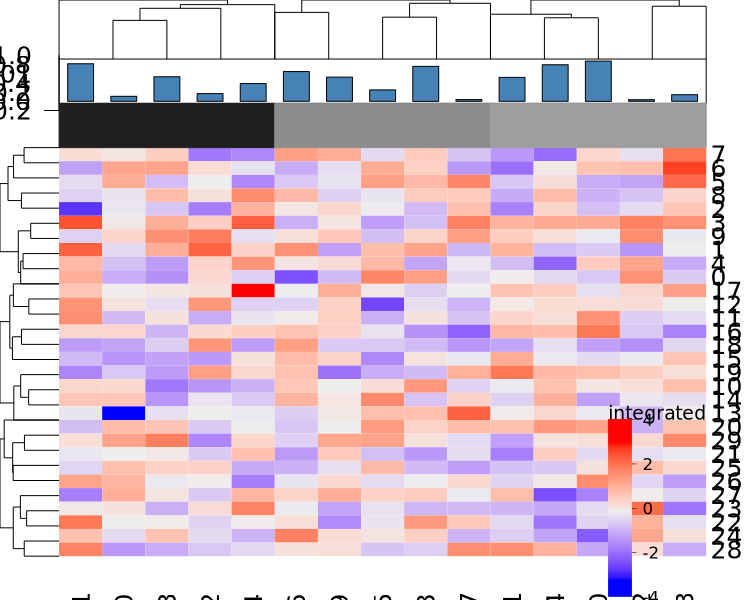

In [3]:
ha_top = HeatmapAnnotation(
    bar=anno_barplot(np.random.rand(n_col)),
    group=col_groups,
)

ht = Heatmap(
    mat,
    name="integrated",
    top_annotation=ha_top,
    column_split=col_groups,
    row_split=row_groups,
)
ht.draw()

## Verifying row and column slicing

When `row_split` and `column_split` are provided, the heatmap is divided into slices.
We can verify the number of slices and that all elements are preserved.

In [4]:
ht2 = Heatmap(
    mat,
    name="verify",
    column_split=col_groups,
    row_split=row_groups,
)
ht2.make_layout()

n_row_slices = len(ht2.row_order_list())
n_col_slices = len(ht2.column_order_list())
total_rows = sum(len(v) for v in ht2.row_order_list())
total_cols = sum(len(v) for v in ht2.column_order_list())

print(f"Row slices: {n_row_slices} (expected 3)")
print(f"Col slices: {n_col_slices} (expected 3)")
print(f"Total rows preserved: {total_rows} == {n_row}")
print(f"Total cols preserved: {total_cols} == {n_col}")

Row slices: 3 (expected 3)
Col slices: 3 (expected 3)
Total rows preserved: 30 == 30
Total cols preserved: 15 == 15


## Combining heatmaps with the `+` operator

Multiple heatmaps can be concatenated horizontally using `+`. The row ordering
from the first (main) heatmap is shared across all heatmaps in the list.
Right-side annotations can be attached to the second heatmap.

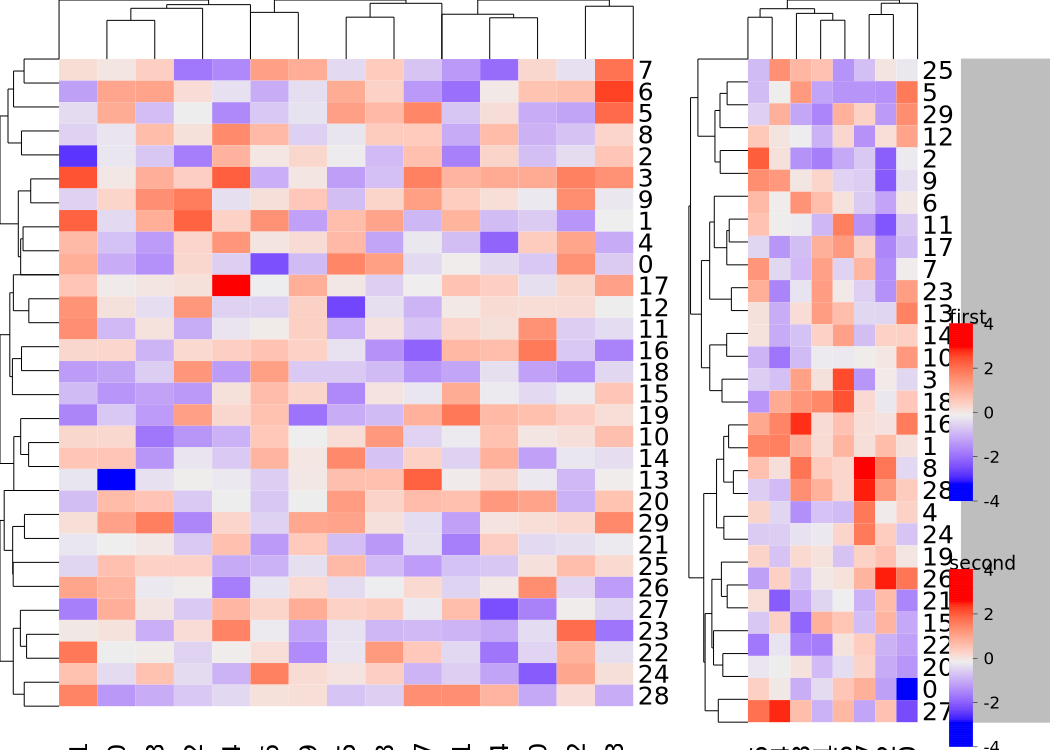

HeatmapList(['first', 'second'], direction='horizontal')

In [5]:
mat2 = np.random.randn(n_row, 8)

ha_right = rowAnnotation(
    score=np.random.randn(n_row),
)

ht_a = Heatmap(mat, name="first", column_split=col_groups, row_split=row_groups)
ht_b = Heatmap(mat2, name="second", right_annotation=ha_right)

ht_list = ht_a + ht_b
ht_list.draw()

## Verifying the combined heatmap list

After combining, we can confirm that the list contains both heatmaps by
inspecting the column order.

In [6]:
ht_list2 = ht_a + ht_b
ht_list2.make_layout()
co = ht_list2.get_column_order()
print(f"Number of heatmaps in list: {len(co)}")
print(f"Has both heatmaps: {len(co) >= 2}")

Number of heatmaps in list: 2
Has both heatmaps: True


## Custom legends

For complex annotations (e.g., barplots) that do not auto-generate legends,
you can build `Legend` objects manually and pass them to `draw()` via
`annotation_legend_list` or `heatmap_legend_list`.

In [7]:
col_fun = color_ramp2([-2, 0, 2], ["blue", "white", "red"])

lgd = Legend(col_fun=col_fun, title="Values", at=[-2, -1, 0, 1, 2])
lgd_discrete = Legend(
    at=[1, 2, 3],
    labels=["Group1", "Group2", "Group3"],
    title="Groups",
    legend_gp={"fill": ["red", "green", "blue"]},
)
packed = pack_legend(lgd, lgd_discrete)
print(f"Packed legend type: {type(packed).__name__}")
print(f"Is Legends: {isinstance(packed, Legends)}")

Packed legend type: Legends
Is Legends: True


## Annotations on all four sides

ComplexHeatmap supports annotations on all four sides of a heatmap:
`top_annotation`, `bottom_annotation`, `left_annotation`, and `right_annotation`.
Top and bottom annotations are column-wise; left and right are row-wise.

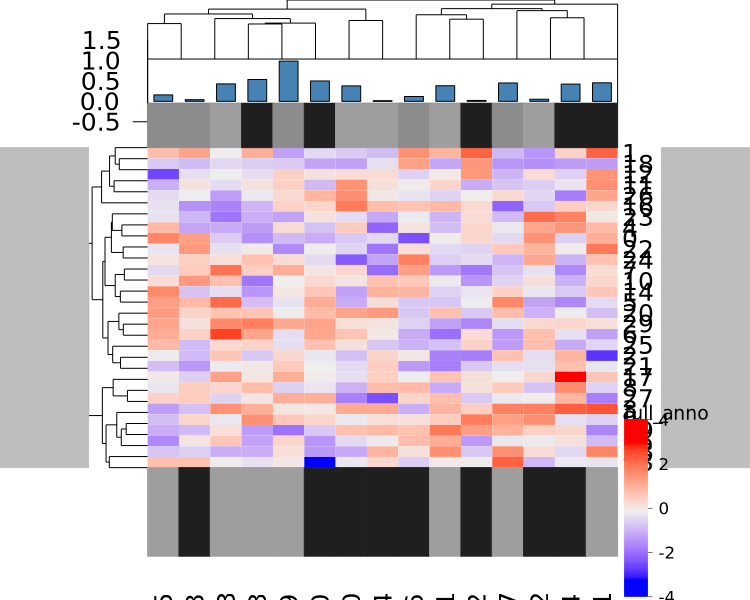

In [8]:
ha_top = HeatmapAnnotation(
    bar=anno_barplot(np.random.rand(n_col)),
    group=col_groups,
)

ha_bottom = HeatmapAnnotation(
    bottom_cat=np.array(["X", "Y"] * (n_col // 2) + ["X"] * (n_col % 2)),
)

ha_left = rowAnnotation(
    left_val=np.random.randn(n_row),
)

ha_right = rowAnnotation(
    score=np.random.randn(n_row),
)

ht_full = Heatmap(
    mat,
    name="full_anno",
    top_annotation=ha_top,
    bottom_annotation=ha_bottom,
    left_annotation=ha_left,
    right_annotation=ha_right,
)
ht_full.draw()

## Verify the four-sided annotation layout

In [9]:
ht_full2 = Heatmap(
    mat,
    name="full_check",
    top_annotation=ha_top,
    bottom_annotation=ha_bottom,
    left_annotation=ha_left,
    right_annotation=ha_right,
)
ht_full2.make_layout()
print(f"Heatmap nrow={ht_full2.nrow}, ncol={ht_full2.ncol}")
print("Four-sided annotation construction: OK")

Heatmap nrow=30, ncol=15
Four-sided annotation construction: OK


## Column splitting with annotations

Column splitting works seamlessly with annotations. The annotation tracks
are also split to match the column slices.

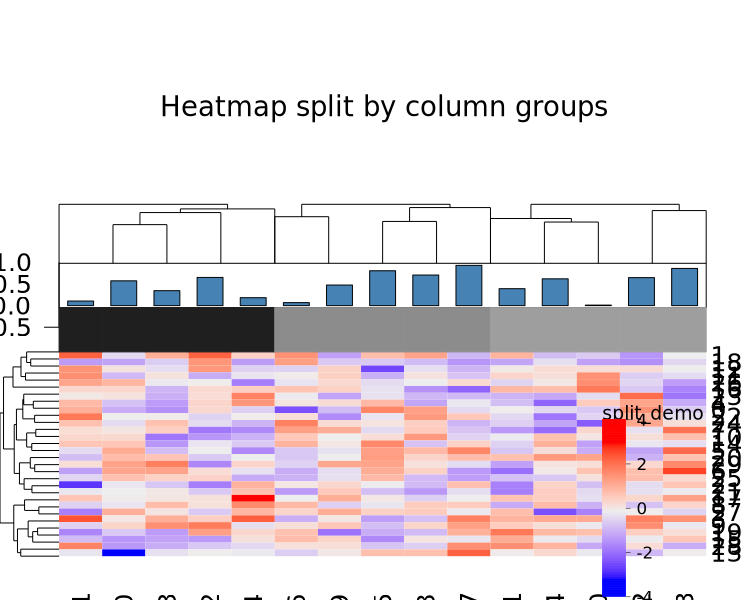

In [10]:
ha_split = HeatmapAnnotation(
    val=anno_barplot(np.random.rand(n_col)),
    cat=col_groups,
)

ht_split = Heatmap(
    mat,
    name="split_demo",
    top_annotation=ha_split,
    column_split=col_groups,
    column_title="Heatmap split by column groups",
)
ht_split.draw()

## Heatmap with row annotations and legends together

A common pattern is to combine row annotations with custom legends. Here we
add a left annotation with `anno_block` style coloring and pass extra legends.

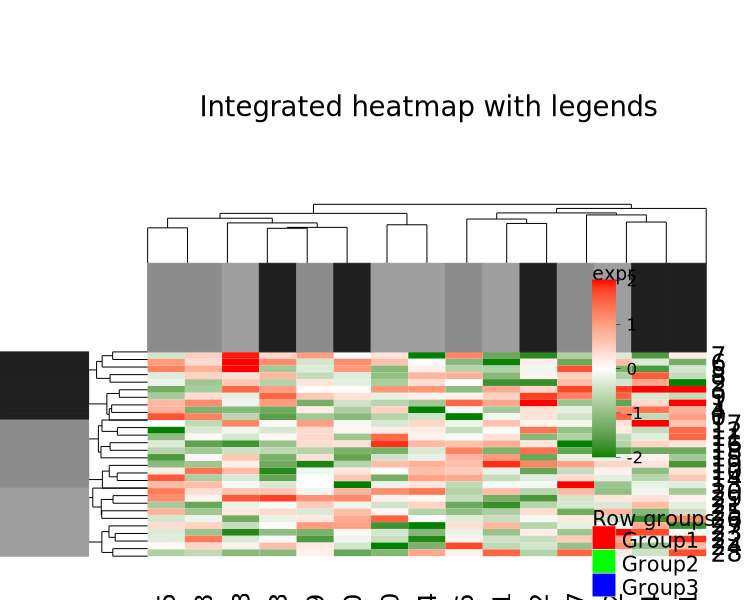

In [11]:
ha_left_block = rowAnnotation(
    block=row_groups,
)

col_fun = color_ramp2([-2, 0, 2], ["green", "white", "red"])

ht_final = Heatmap(
    mat,
    name="expr",
    col=col_fun,
    row_split=row_groups,
    left_annotation=ha_left_block,
    top_annotation=HeatmapAnnotation(group=col_groups),
    column_title="Integrated heatmap with legends",
)

lgd_groups = Legend(
    at=[1, 2, 3],
    labels=["Group1", "Group2", "Group3"],
    title="Row groups",
    legend_gp={"fill": ["red", "green", "blue"]},
)

ht_final.draw(              annotation_legend_list=[lgd_groups])

## Concatenating heatmaps and row annotations

Row annotations can also be concatenated using the `+` operator. This is
useful for building multi-panel figures with shared row ordering.

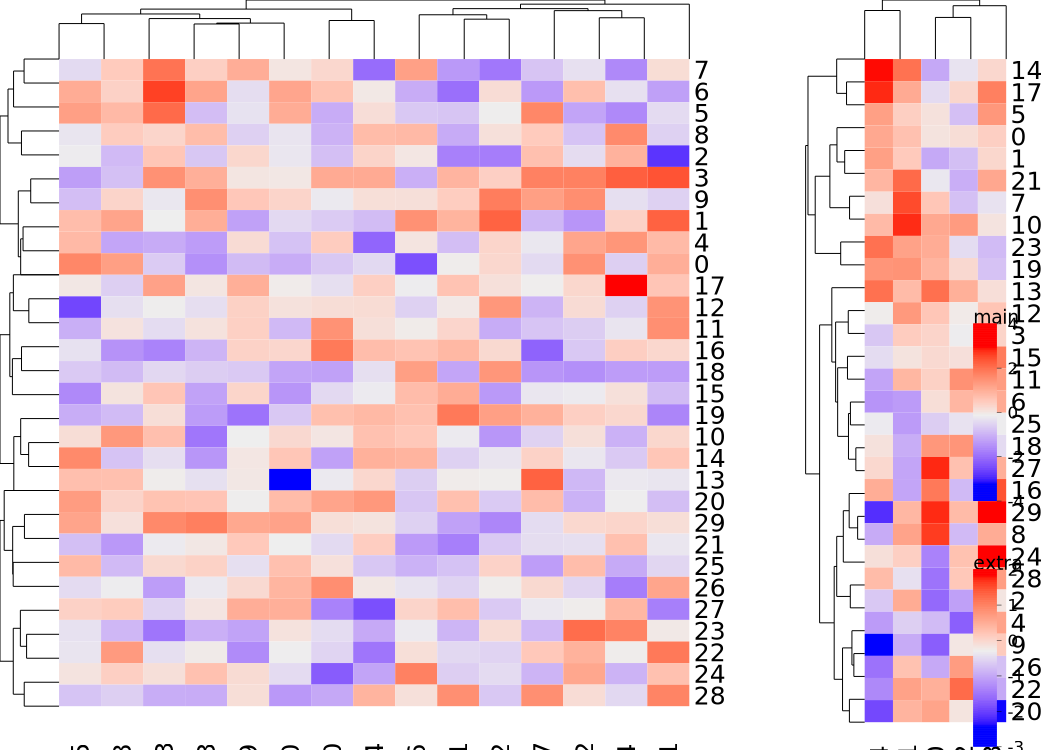

HeatmapList(['main', '?', 'extra'], direction='horizontal')

In [12]:
ht_main = Heatmap(mat, name="main", row_split=row_groups)
ra = rowAnnotation(pts=anno_points(np.random.randn(n_row)))
ht_extra = Heatmap(np.random.randn(n_row, 5), name="extra")

ht_combined = ht_main + ra + ht_extra
ht_combined.draw()

## Summary

This tutorial covered the key integration techniques in ComplexHeatmap:

- Heatmaps with top annotations and row/column splitting
- Verifying slice counts and element preservation after splitting
- Concatenating multiple heatmaps with shared row ordering via `+`
- Building and packing custom legends with `Legend` and `pack_legend`
- Annotations on all four sides (top, bottom, left, right)
- Column splitting with annotations
- Combining heatmaps, row annotations, and custom legends in one figure